In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
df = sns.load_dataset("tips")
df.to_csv(r"data\tips.csv", index = False)

In [74]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [58]:
print(f"Rows: {df.shape[0]} & Columns: {df.shape[1]}") #Rows: 244 & Columns: 7

Rows: 244 & Columns: 7


In [59]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [60]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [61]:
for i in df.columns:
    print(f"{i}: {df[i].isnull().sum()} | {((df[i].isnull().sum())/(len(df)))*100}")

total_bill: 0 | 0.0
tip: 0 | 0.0
sex: 0 | 0.0
smoker: 0 | 0.0
day: 0 | 0.0
time: 0 | 0.0
size: 0 | 0.0


In [ ]:
df.describe()

In [72]:
for col in df.select_dtypes(include="number").columns:
    print(f"Skewness for {col}: {df[col].skew():.2f}")

Skewness for total_bill: 1.13
Skewness for tip: 1.47
Skewness for size: 1.45


In [73]:
df[df.duplicated()] #A single row iidentified as duplicate. keeping for now

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [71]:
for col in df.select_dtypes(include="category").columns:
    print(f"{col}: {df[col].nunique()} unique categories")

sex: 2 unique categories
smoker: 2 unique categories
day: 4 unique categories
time: 2 unique categories


In [63]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)

IQR = Q3 - Q1
Lower_bound = Q1 - 1.5*IQR
Upper_bound = Q3 + 1.5*IQR

print(df[(df["total_bill"] < Lower_bound) | (df["total_bill"] > Upper_bound)])
print(df[(df["total_bill"] < Lower_bound) | (df["total_bill"] > Upper_bound)].shape) #(9, 7)

     total_bill    tip     sex smoker   day    time  size
59        48.27   6.73    Male     No   Sat  Dinner     4
102       44.30   2.50  Female    Yes   Sat  Dinner     3
142       41.19   5.00    Male     No  Thur   Lunch     5
156       48.17   5.00    Male     No   Sun  Dinner     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
182       45.35   3.50    Male    Yes   Sun  Dinner     3
184       40.55   3.00    Male    Yes   Sun  Dinner     2
197       43.11   5.00  Female    Yes  Thur   Lunch     4
212       48.33   9.00    Male     No   Sat  Dinner     4
(9, 7)


In [64]:
for i in df.select_dtypes(include=np.number).columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    Lower_bound = Q1 - 1.5 * IQR
    Upper_bound = Q3 + 1.5 * IQR

    print(f"Q1 for {i} = {Q1}")
    print(f"Q3 for {i} = {Q3}")
    print(f"IQR for {i} = {IQR}")
    print(f"Lower bound for {i} = {Lower_bound}")
    print(f"Upper bound for {i} = {Upper_bound}")
    print("Outlier rows: ", df[(df[i] < Lower_bound) | (df[i] > Upper_bound)].shape[0])
    print("\n")

Q1 for total_bill = 13.3475
Q3 for total_bill = 24.127499999999998
IQR for total_bill = 10.779999999999998
Lower bound for total_bill = -2.8224999999999945
Upper bound for total_bill = 40.29749999999999
Outlier rows:  9


Q1 for tip = 2.0
Q3 for tip = 3.5625
IQR for tip = 1.5625
Lower bound for tip = -0.34375
Upper bound for tip = 5.90625
Outlier rows:  9


Q1 for size = 2.0
Q3 for size = 3.0
IQR for size = 1.0
Lower bound for size = 0.5
Upper bound for size = 4.5
Outlier rows:  9




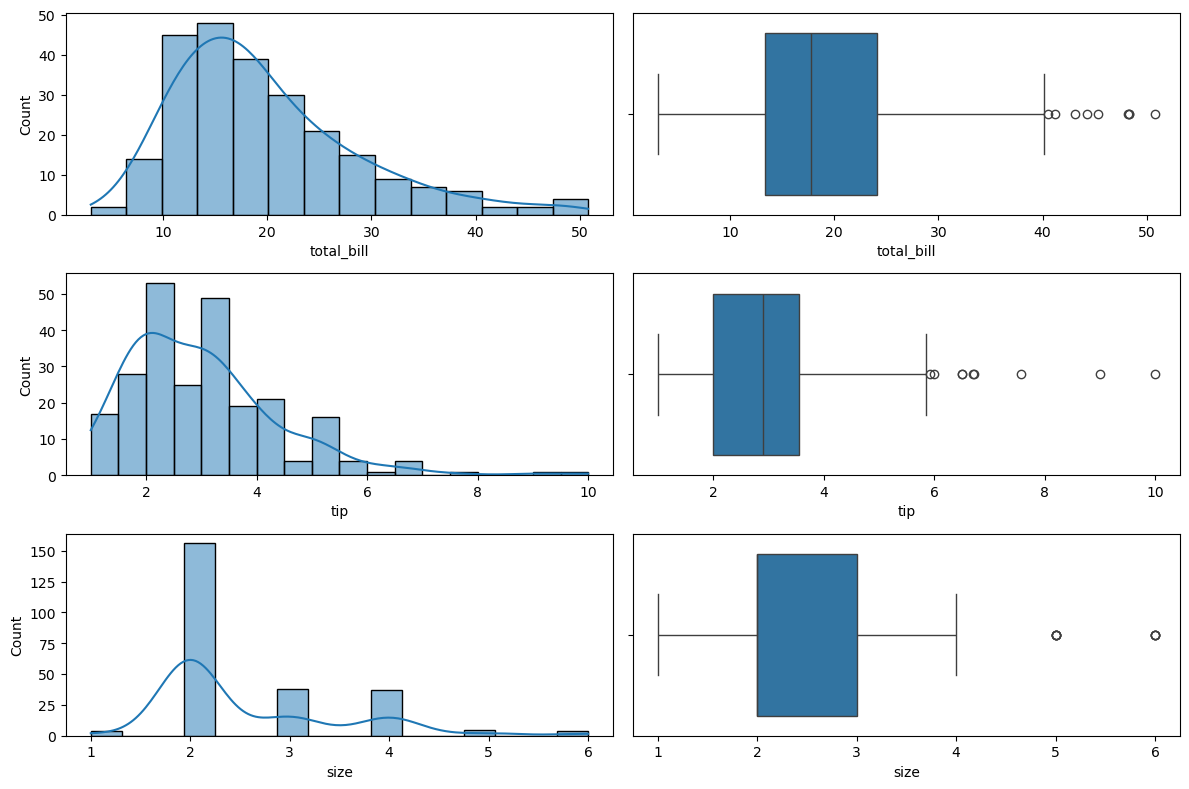

In [65]:
fig, ax = plt.subplots(3, 2, figsize=(12, 8))

columns = df.select_dtypes(include=np.number).columns

for j, i in enumerate(columns):
    sns.histplot(data=df, x=i, ax=ax[j, 0], kde=True)
    sns.boxplot(data=df, x=i, ax=ax[j, 1])

plt.tight_layout()
plt.show()

In [66]:
for i in df.select_dtypes(include='category').columns:
    summary = pd.DataFrame({
        "Count": df[i].value_counts(),
        "Percentage (%)": (df[i].value_counts(normalize=True) * 100).round(2)
    })

    print("\n")
    print(f"Category Report: {i}")
    print(summary)



Category Report: sex
        Count  Percentage (%)
sex                          
Male      157           64.34
Female     87           35.66


Category Report: smoker
        Count  Percentage (%)
smoker                       
No        151           61.89
Yes        93           38.11


Category Report: day
      Count  Percentage (%)
day                        
Sat      87           35.66
Sun      76           31.15
Thur     62           25.41
Fri      19            7.79


Category Report: time
        Count  Percentage (%)
time                         
Dinner    176           72.13
Lunch      68           27.87


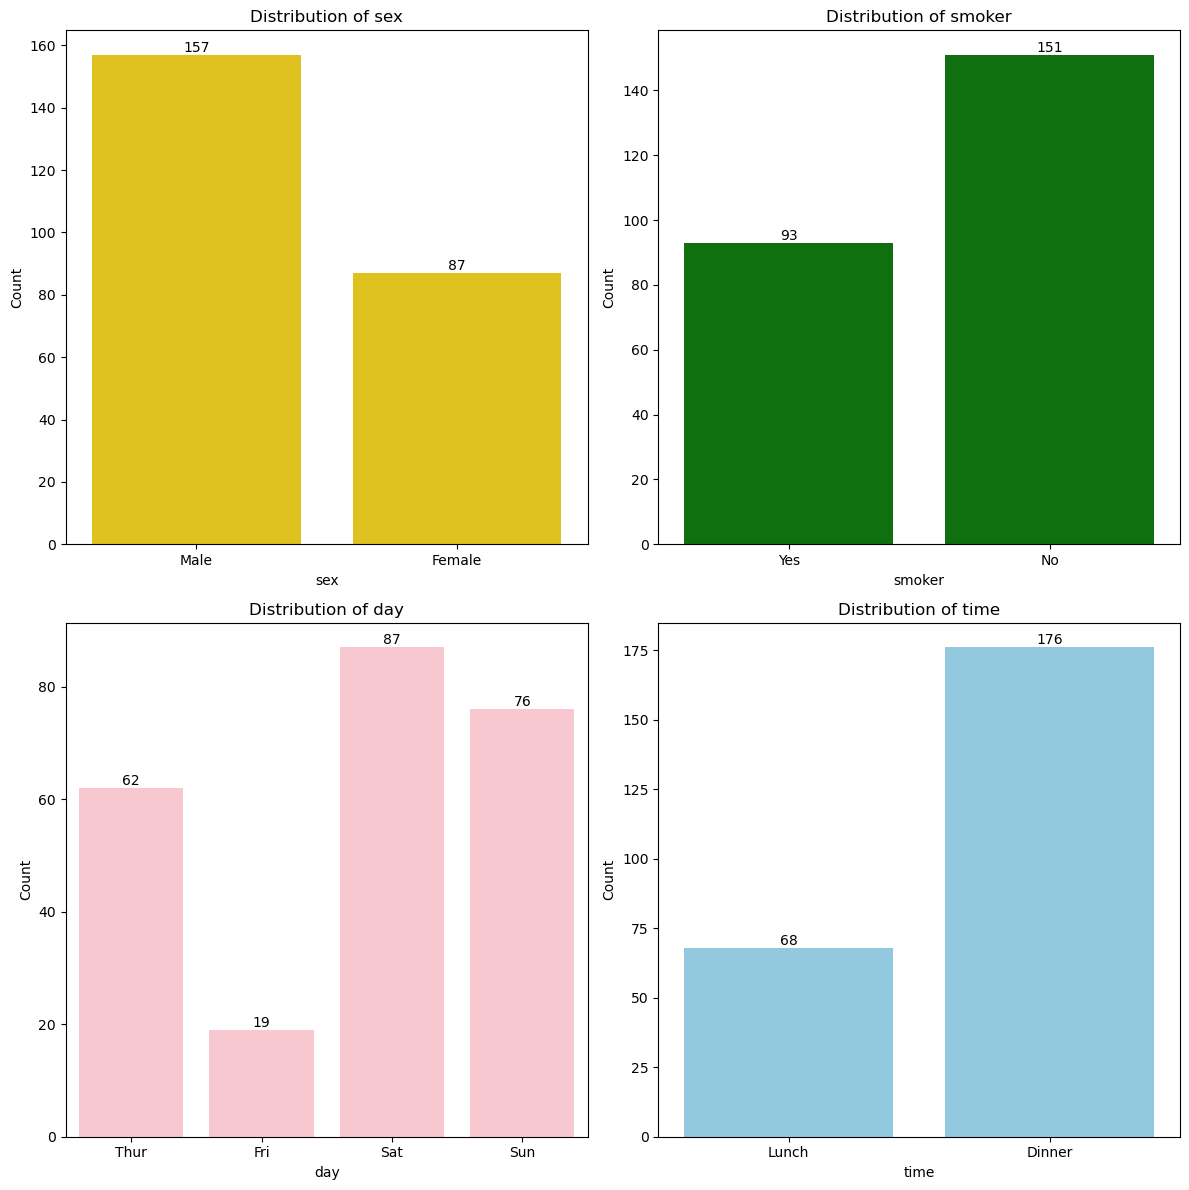

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include="category").columns
colors = ["gold", "green", "pink", "skyblue"]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color=colors[i])
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
    for container in axes[i].containers:
        axes[i].bar_label(container)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()